**Disciplina: ACA052 - Meteorologia Sinótica I**

Monitor: Ronald Guiuseppi Ramírez Nina

File: Aula_06.ipynb

# **Altura Geopotencial em Níveis baixos (850 hPa), médios (500 hPa) e Superiores (250 hPa) a partir do Modelo Global Forecast System (GFS)**

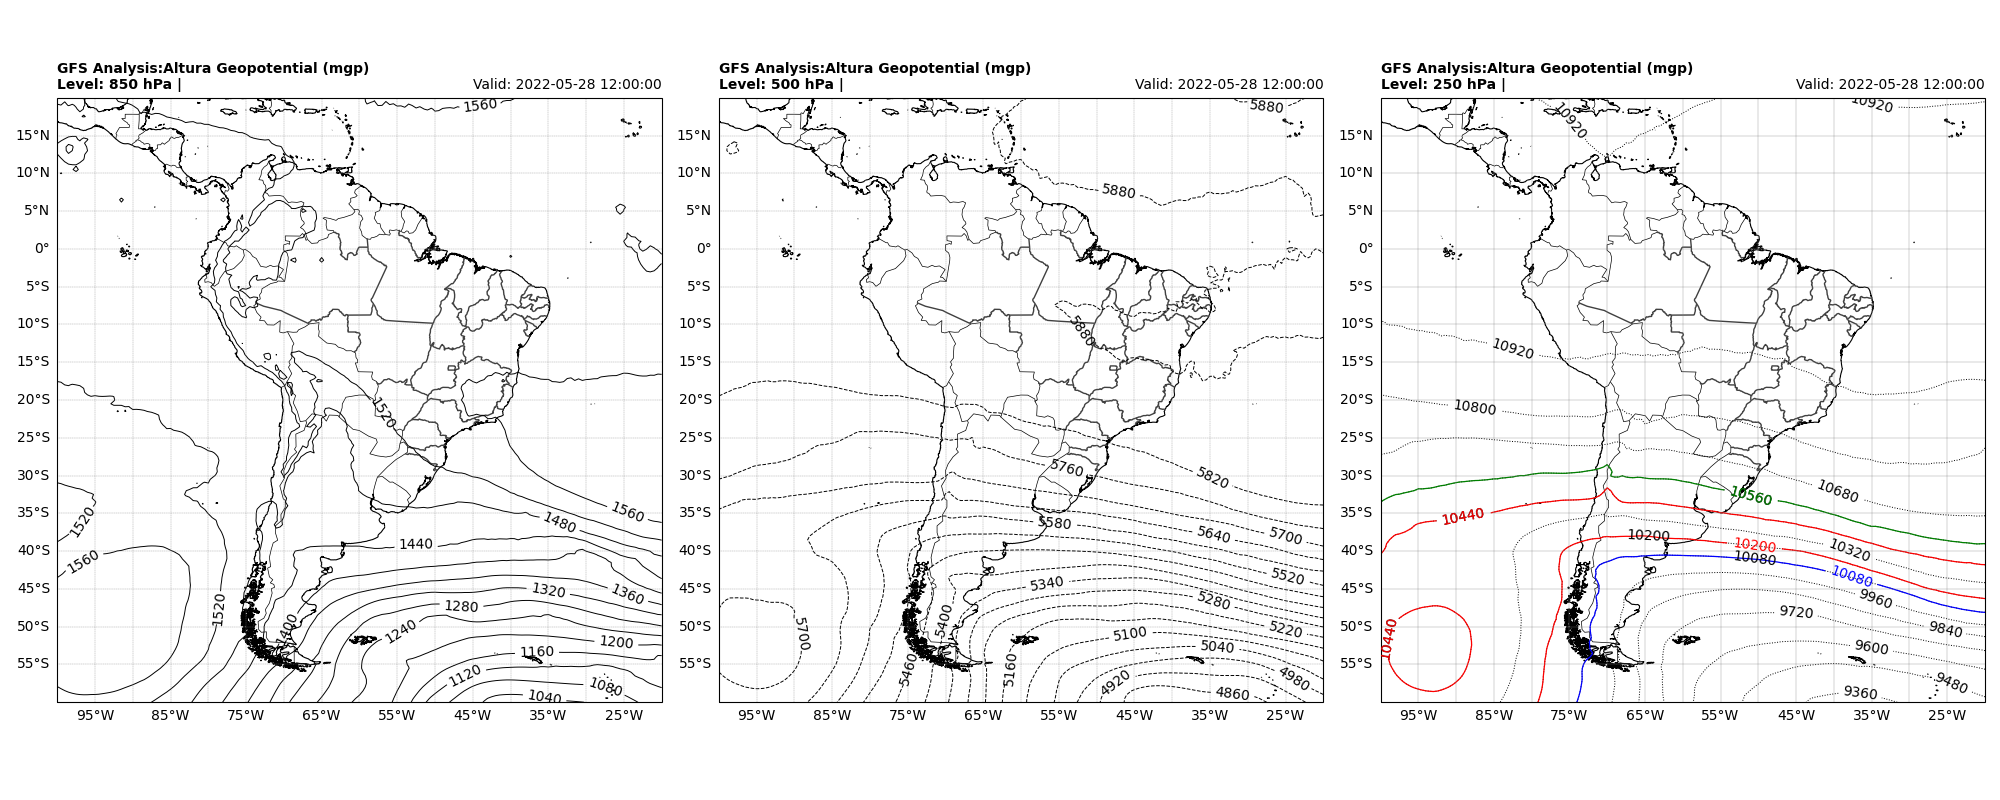

# **Instalando pacotes para o processamento dos dados grib**

In [1]:
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no colab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

Found existing installation: Shapely 1.8.2
Uninstalling Shapely-1.8.2:
  Successfully uninstalled Shapely-1.8.2
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 198 kB 25.7 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 10.8 MB 50.6 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 41.7 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 37.3 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 12.1 MB 36.7 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing 

**Instalando o pygrib**

In [2]:
# Instalando o pacote "pygrib"
!pip install pygrib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 16.5 MB 33.3 MB/s 
     |████████████████████████████████| 6.3 MB 62.0 MB/s 


# **Altura Geopotencial**

A altura geopotencial (mgp) representa a altura real de uma superfície de pressão atmosférica acima da superfície terrestre, considerando a temperatura média da camada inferior. 

Regiões frias apresentam alturas geopotencias menores do que regiões quentes. Os cavados estão relacionados a massas de ar frias. As cristas estão relacionadas com massas de ar quente ou relacionadas a processos de subsidência. A subsidência aquece o ar da coluna atmósferica devido à compressão adiabática, portanto gera um área de alta altura geopotencial. 


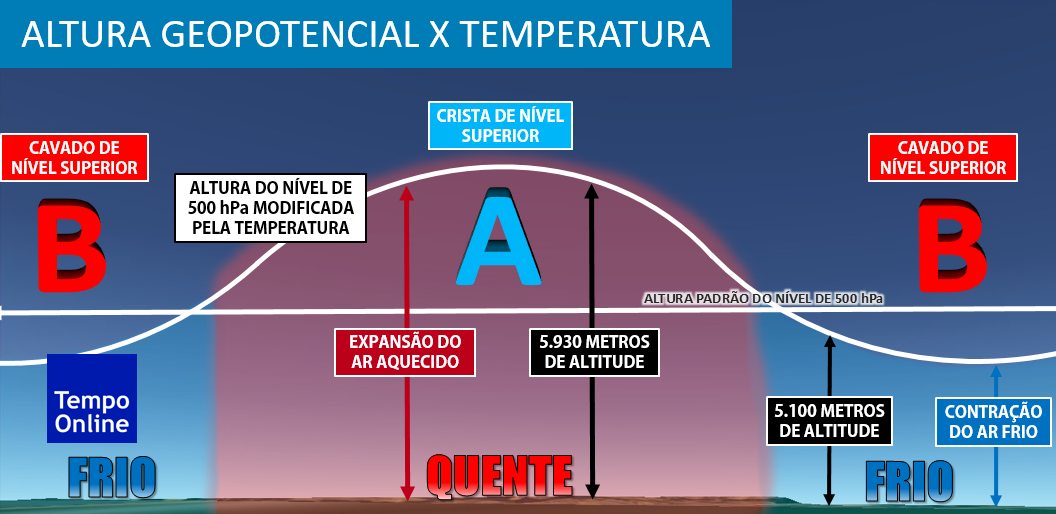


**Fonte: Tempo Online**

**Objetivos**

- Fazer mapas do campo de altura geopotencial em níveis baixos - 850 hPa.
- Fazer mapas do campo de altura geopotencial em níveis médios - 500 hPa.
- Fazer mapas do campo de altura geopotencial em níveis altos  - 250 hPa.
- Trazar as cristas e cavados.

**Cavado**

Um cavado é uma região de uma relativa baixa altura geopotencial em uma superfície isobárica. Em um cavado as isohipsas não são fechadas. 

**Crista**

Uma crista é uma região de uma relativa alta altura geopotencial em uma superfície isobárica. Em uma crista as isohipsas não são fechadas. 

No Hemisfério Sul, o escoamento ao longo de um **cavado** apresenta curvatura ciclónica (ou giro horário) e o escoamento ao longo de uma **crista** apresenta curvatura anticiclónica (ou giro antihorário).  

**Na dianteira do eixo do cavado** se produz tempo ruim porque forma-se nebulosidade, produzem-se precipitações, às vecez ventos fortes e a pressão atmosférica em superfície começa a diminuir. Na dianteira de um cavado se produzem movimentos verticais ascendentes (entre o solo e os 10000 mêtros). 


**Na dianteira do eixo da crista** é uma região de bom tempo. A nebulosidade se dissipa, pouco vento e a pressão atmosférica sobe.

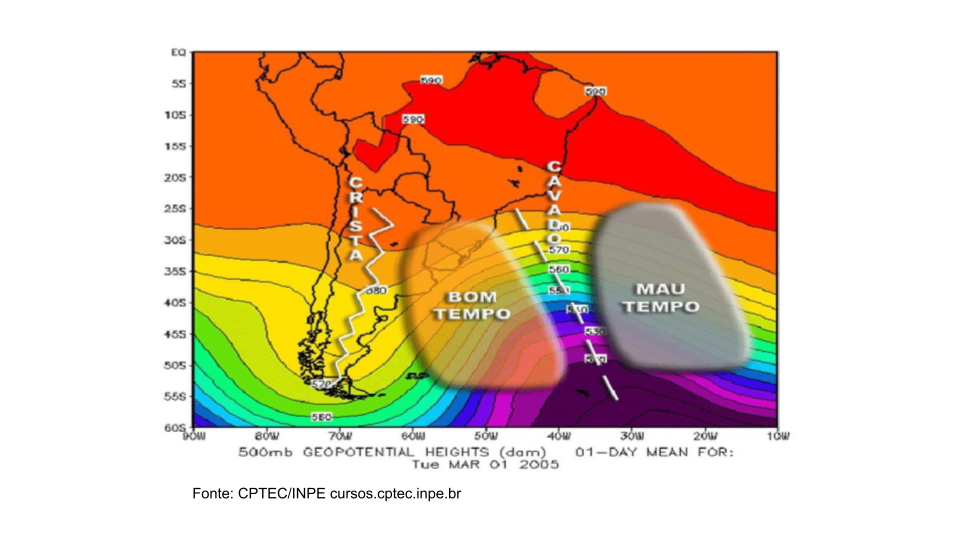

**Importando pacotes de processameto e geração de mapas**

In [3]:
print("1. Importar pacotes")
# Pacotes de processamento de dados 
import numpy as np
# Pacote para ler e processar dados grib
import pygrib

# Pacotes para gerar mapas
import matplotlib.pyplot as plt
import cartopy.crs as ccrs # Pacote para mapas (sistema de referência cooordenado)
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Importar o drive para acesso aos dados
print("2. Importar drive")
from google.colab import drive
drive.mount('/content/drive')

print("3. Terminou de importar os pacotes")

1. Importar pacotes
2. Importar drive
Mounted at /content/drive
3. Terminou de importar os pacotes


**Acessando ao website do GFS para fazer o download dos dados de análise ou previsão**

O primer passo é acessar ao seguinte link:

https://nomads.ncep.noaa.gov/

Ou escrever no buscado de www.google.com o seguinte: **gfs nomads data** e fazer clic na primeira opção

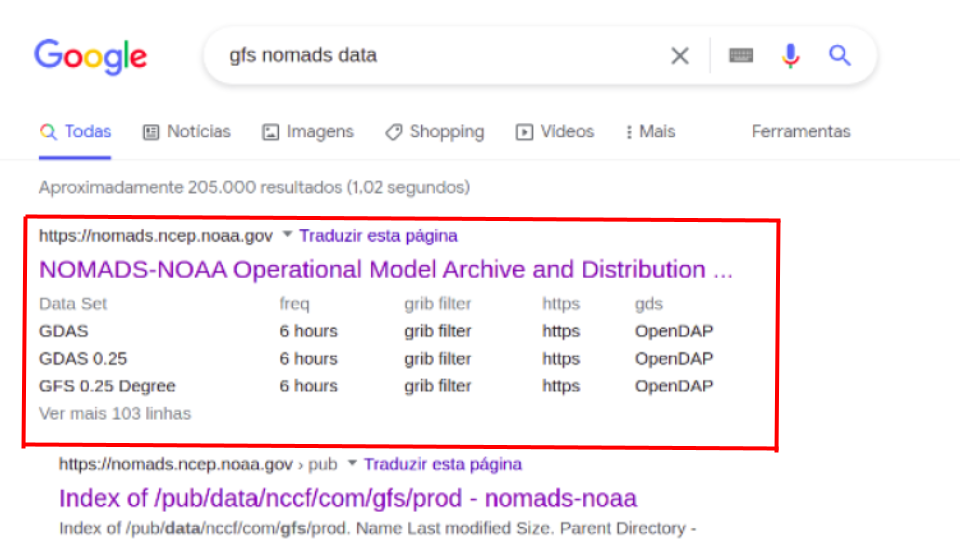

Depois de entrar ao link ou dar clic na primeira opção do site do **GFS**. Seleccionar os dados de análise ou previsão. Escolher o produto de interesse do **GFS** segundo a resolução de interesse e dar **clic** na opção **grib filter**

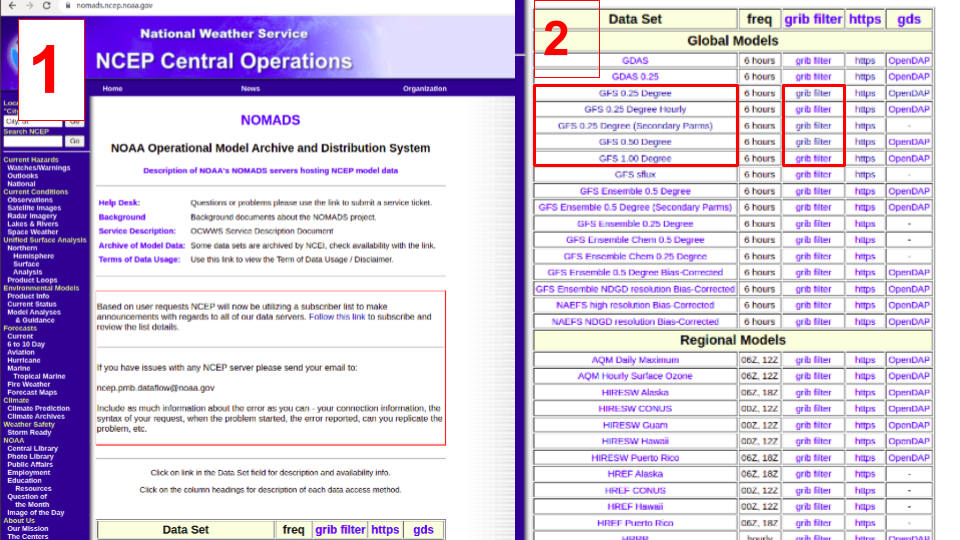

Depois de fazer clic em **grib filter**, vai aprecer as seguintes opções:

1º Fazer clic em uma data da sua escolha **gfs_20220525**.

2º Fazer clic em uma hora da sua escolha **12**

3º Fazer clic na opção **atmos**

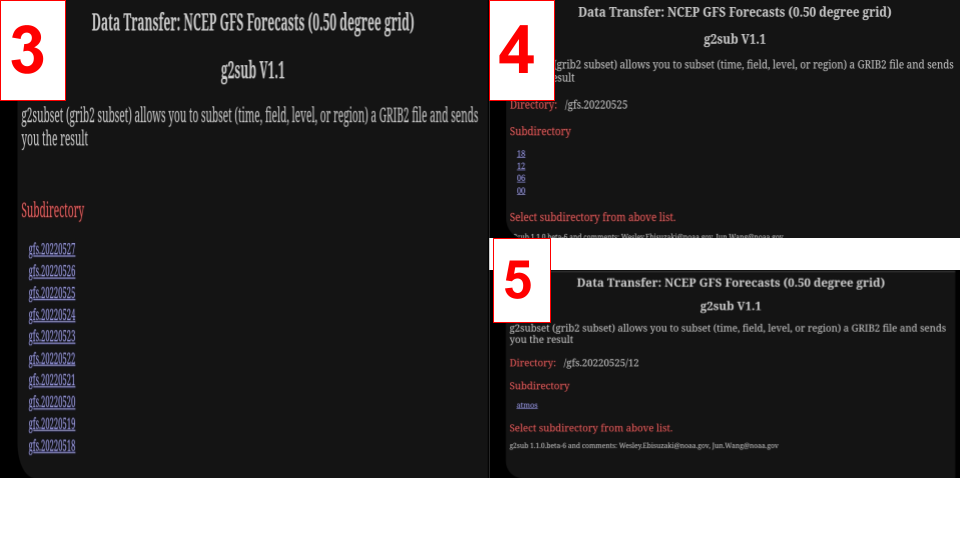

Depois de fazer esses 3 pasos, vocês acessaram ao seguinte site:

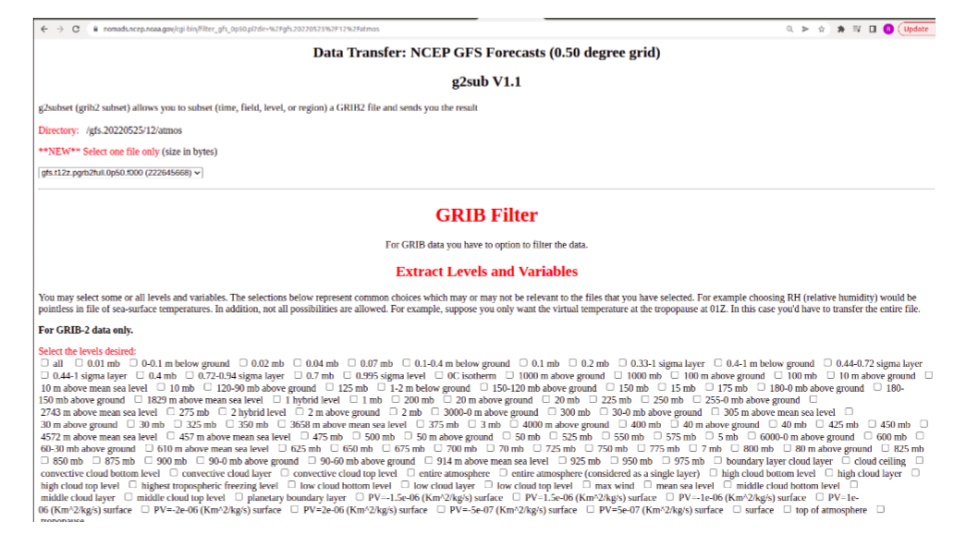

Na secção **Select the levels desired**, escolher:

- 1000mb, 200mb, 250mb, 300mb, 500mb, 700mb, 750mb, 850mb, 925mb, 2m above ground, mean sea level, surface. 

Na seção **Select the variables desired**, escolher:

- all

Na seção **Extract Subregion**, escolher:

- Escolher a opção por default, ou seja:

left longitude: 0      right longitude: 360

top latitude: 90        bottom latitude: -90

Finalmente Fazer clic em **Start download** 

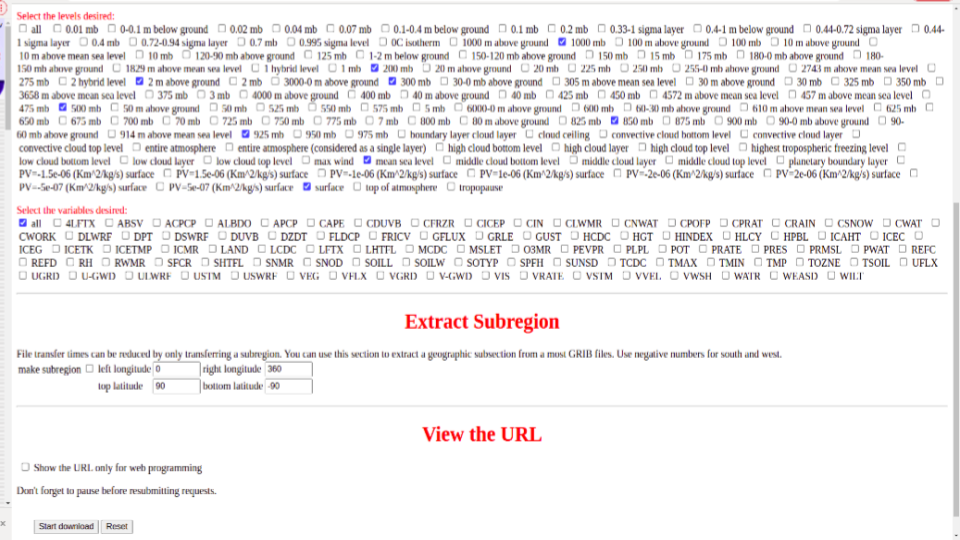

O seguinte passo é subir o file **grib** a sua pasta de trabalho do drive

**Código para Fazer mapas de Altura Geopotencial em 850 hPa, 500 hPa e 250 hPa**

In [4]:
print("4. Ler arquivo grib")
# Salvar o path do arquivo grib em um objeto --> "path"
path = '/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_06/gfs.t12z.pgrb2full.0p50.f000'
# Ler o arquivo grib 
gfs = pygrib.open(path)

# Mostrar a lista de variáveis do nosso arquivo grib
print("5. Lista de variáveis do arquivo grib")
print('                         ')
print('--------------------------------------------------------------------------------------------------')
f = open("variables.txt", "w")

for variables in gfs:
  print(variables)
  print(variables, file=f)
f.close()

4. Ler arquivo grib
5. Lista de variáveis do arquivo grib
                         
--------------------------------------------------------------------------------------------------
1:Pressure reduced to MSL:Pa (instant):regular_ll:meanSea:level 0:fcst time 0 hrs:from 202205281200
2:Visibility:m (instant):regular_ll:surface:level 0:fcst time 0 hrs:from 202205281200
3:Wind speed (gust):m s**-1 (instant):regular_ll:surface:level 0:fcst time 0 hrs:from 202205281200
4:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281200
5:Temperature:K (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281200
6:Relative humidity:% (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281200
7:Total Cloud Cover:% (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281200
8:Specific humidity:kg kg**-1 (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281

**Ver os index para cada nível vertical de uma variável**

In [5]:
# Olhando os index para cada nível na varíavel de Altura geopotencial
hgt = gfs.select(name = 'Geopotential Height')
print("6. Ver os index dos níveis de pressão")
hgt

6. Ver os index dos níveis de pressão


[4:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202205281200,
 20:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 25000 Pa:fcst time 0 hrs:from 202205281200,
 36:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 30000 Pa:fcst time 0 hrs:from 202205281200,
 52:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 40000 Pa:fcst time 0 hrs:from 202205281200,
 68:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 50000 Pa:fcst time 0 hrs:from 202205281200,
 84:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 60000 Pa:fcst time 0 hrs:from 202205281200,
 100:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 70000 Pa:fcst time 0 hrs:from 202205281200,
 116:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 75000 Pa:fcst time 0 hrs:from 202205281200,
 132:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 80000 Pa:fcst time 0 hrs:

**Fazendo mapas com a Altura Geopotencial nos níveis de 850 hPa, 500 hPa, 250 hPa**

Criando variáveis (ou objetos) do **hgt** para os níveis de 850 hPa, 500 hPa e 250 hPa. 

- Nível de 850 hPa -> **hgt_850**
- Nível de 500 hPa -> **hgt_500**
- Nível de 250 hPa -> **hgt_250**

**Criando a Figura**

7. Criando variáveis para cada nível de pressão
8. Obter informalções do arquivo grib
Init: 2022-05-28 12:00:00UTC
Run: 12Z
Forecast: +0
Valid: 2022-05-28 12:00:00 UTC
9. Seleccionar extensão do mapa
10. Ler o dado sobre a região especificada - América do Sul
11. Criar a Figura
12. Asignar projeção ao mapa em 850 hPa
13. Agregando linhas de costa, límites entre paises e linhas de grade
14. Agregando os estado de Brasil, The USA, e outros paises
15. Agregando intervalos de contorno
16. Fazendo plot da variável
17. Fazendo o mapa para o nível de 500 hPa
18. Agregando linhas de costa, límites entre paises e linhas de grade
19. Agregando os estado de Brasil, The USA, e outros paises
20. Agregando intervalos de contorno
21. Fazendo plot da variável
22. Fazendo o mapa para o nível de 250 hPa
23. Agregando linhas de costa, límites entre paises e linhas de grade
24. Agregando os estado de Brasil, The USA, e outros paises
25. Agregando intervalos de contorno
26. Fazendo plot da variável
27. Res

/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/10m/physical/ne_10m_coastline.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces_lines.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)


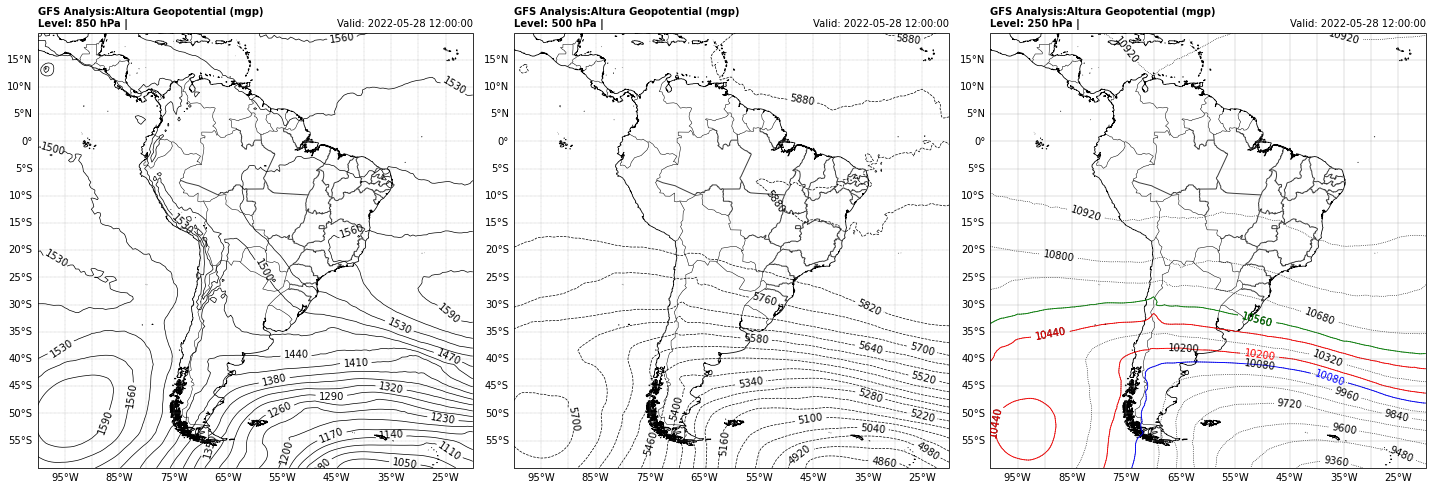

In [6]:
# Criando as variáveis de hgt para cada nível de pressão
print("7. Criando variáveis para cada nível de pressão")

# Nível 850 hPa
hgt_850 = gfs.select(name = "Geopotential Height")[9]

# Nível de 500 hPa
hgt_500 = gfs.select(name = "Geopotential Height")[4]

# Nível de 250 hPa
hgt_250 = gfs.select(name = "Geopotential Height")[1]

# Obter informações do arquivo
print("8. Obter informalções do arquivo grib")
init  = str(hgt_850.analDate)        # Init date / time
run   = str(hgt_850.hour).zfill(2)   # Run
ftime = str(hgt_850.forecastTime)    # Forecast hour
valid = str(hgt_850.validDate)       # Valid date / time
print('Init: ' + init + 'UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Seleccionar a extensão do mapa
print("9. Seleccionar extensão do mapa")
lat_min = -60
lat_max = 20
lon_min = -100
lon_max = -20
# Extensão do mapa
extent = [lon_min, lat_min, lon_max, lat_max]

# Ler o dado e extrair informação sobre a região especificada
print("10. Ler o dado sobre a região especificada - América do Sul")
# Nível de 850
hgt_850, lats, lons = hgt_850.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 500
hgt_500, lats, lons = hgt_500.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 250
hgt_250, lats, lons = hgt_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)

# ----------------------------------------------------------------------------------------------------------------
# Crian uma figura
print("11. Criar a Figura")
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,8), subplot_kw={'projection':ccrs.PlateCarree()}, sharey=True)

# FAZENDO O PRIMER MAPA PARA O NÍVEL DE 850 hPa

# ***********************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("12. Asignar projeção ao mapa em 850 hPa")
ax[0].set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax[0].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax[0].yaxis.set_major_formatter(LongitudeFormatter())

print("13. Agregando linhas de costa, límites entre paises e linhas de grade")
# Agregar linhas de costa
ax[0].coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar os límites entre paises
ax[0].add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
# Agregar linhas de grade
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("14. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax[0].add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# Definindo intervalos de contorno
print("15. Agregando intervalos de contorno")
hgt_850min = 600
hgt_850max = 1600
interval = 30
levels = np.arange(hgt_850min, hgt_850max, interval)

# plot da variável
print("16. Fazendo plot da variável")
img_850 = ax[0].contour(lons, lats, hgt_850, colors = 'black', linestyles = 'solid', linewidths = 0.7, levels = levels)
ax[0].clabel(img_850, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'black')

# Agregando titulo ao mapa
ax[0].set_title('GFS Analysis:Altura Geopotential (mgp)\nLevel: 850 hPa |' , fontweight='bold', fontsize=10, loc='left')
ax[0].set_title('Valid: ' + valid, fontsize=10, loc='right')

# ------------------------------------------------------------------------------------------------------------

# FAZENDO O SEGUNDO MAPA PARA O NÍVEL DE 500 hPa

# ************************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("17. Fazendo o mapa para o nível de 500 hPa")
ax[1].set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax[1].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax[1].yaxis.set_major_formatter(LongitudeFormatter())

print("18. Agregando linhas de costa, límites entre paises e linhas de grade")
# Agregar linhas de costa
ax[1].coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar os límites entre paises
ax[1].add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
# Agregar linhas de grade
gl = ax[1].gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("19. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax[1].add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# Definindo intervalos de contorno
print("20. Agregando intervalos de contorno")
hgt_500min = 4320
hgt_500max = 6500
interval = 60
levels = np.arange(hgt_500min, hgt_500max, interval)

# plot da variável
print("21. Fazendo plot da variável")
img_500 = ax[1].contour(lons, lats, hgt_500, colors = 'black', linestyles = '--', linewidths = 0.7, levels = levels)
ax[1].clabel(img_500, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'black')

# Agregando titulo ao mapa
ax[1].set_title('GFS Analysis:Altura Geopotential (mgp)\nLevel: 500 hPa |' , fontweight='bold', fontsize=10, loc='left')
ax[1].set_title('Valid: ' + valid, fontsize=10, loc='right')

# ------------------------------------------------------------------------------------------------------------

# FAZENDO O TERCEIRO MAPA PARA O NÍVEL DE 250 hPa

# ************************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("22. Fazendo o mapa para o nível de 250 hPa")
ax[2].set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax[2].xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax[2].yaxis.set_major_formatter(LongitudeFormatter())

print("23. Agregando linhas de costa, límites entre paises e linhas de grade")
# Agregar linhas de costa
ax[2].coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar os límites entre paises
ax[2].add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
# Agregar linhas de grade
gl = ax[2].gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyles='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("24. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax[2].add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# Definindo intervalos de contorno
print("25. Agregando intervalos de contorno")
hgt_250min = 9000
hgt_250max = 11000
interval = 120
levels = np.arange(hgt_250min, hgt_250max, interval)

# plot da variável
print("26. Fazendo plot da variável")
img_250 = ax[2].contour(lons, lats, hgt_250, colors = 'black', linestyles = 'dotted',linewidths = 0.7, levels = levels)
ax[2].clabel(img_250, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'black')

# Agregando titulo ao mapa
ax[2].set_title('GFS Analysis:Altura Geopotential (mgp)\nLevel: 250 hPa |' , fontweight='bold', fontsize=10, loc='left')
ax[2].set_title('Valid: ' + valid, fontsize=10, loc='right')

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# FAZENDO ISOHIPSAS PARA A LOCALIZAÇÃO DO JATO
print("27. Resaltar as isohipsas para localizar o jato")
# Jato Polar Norte    -> [10200 mgp - 10440 mgp]
hgt_polar_norte = np.arange(10200, 10441, 240)
JPN = ax[2].contour(lons, lats, hgt_250, colors = 'red', linestyles = 'solid', linewidths = 0.9, levels = hgt_polar_norte)
ax[2].clabel(JPN, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'red')

# Jato Polar Sur      -> Menor ou igual 10080 mgp 
hgt_polar_sul = np.arange(10080, 10081, 100)
JPS = ax[2].contour(lons, lats, hgt_250, colors = 'blue', linestyles = 'solid', linewidths = 0.9, levels = hgt_polar_sul)
ax[2].clabel(JPS, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'blue')

# Jato Subtropical    -> Maior ou igual 10560 mgp
hgt_subtropical = np.arange(10560, 10561, 100)
JST = ax[2].contour(lons, lats, hgt_250, colors = 'green', linestyles = 'solid', linewidths = 0.9, levels = hgt_subtropical)
ax[2].clabel(JST, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'green')

# Menos espaços em branco
fig.tight_layout()

print("28. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_06/hgt_' + f'{init}.png', format='png', dpi = 100)

# **Atividade de Aula**

Fazer o seguinte mapa com as seguintes características:

- Velocidade do vento no nível de 250 hPa maior ou igual a 30 m/s (detecção do jato de altos níveis). Para calcular a magnitude do vento lembrar do seguinte:

 mag_vento² = (u² + v²)

 Para o vento utilizar a função **contourf**

- Altura geopotencial em 250 hPa (com intervalos de 120 mgp). 

Utilizar o critério de detecção jato de altos níveis segundo a isohipsa:  

- Jato Polar Ramo Norte: configurar as isohipsas de 10200 mgp e 10440 mgo de cor **vermelho**.

- Jato Polar Ramo Sul: configurar a isohipsa de 10080 mgp de cor **azul**.

- Jato Subtropical: configurar a isohipsa de 10560 mgp de cor **verde**. 

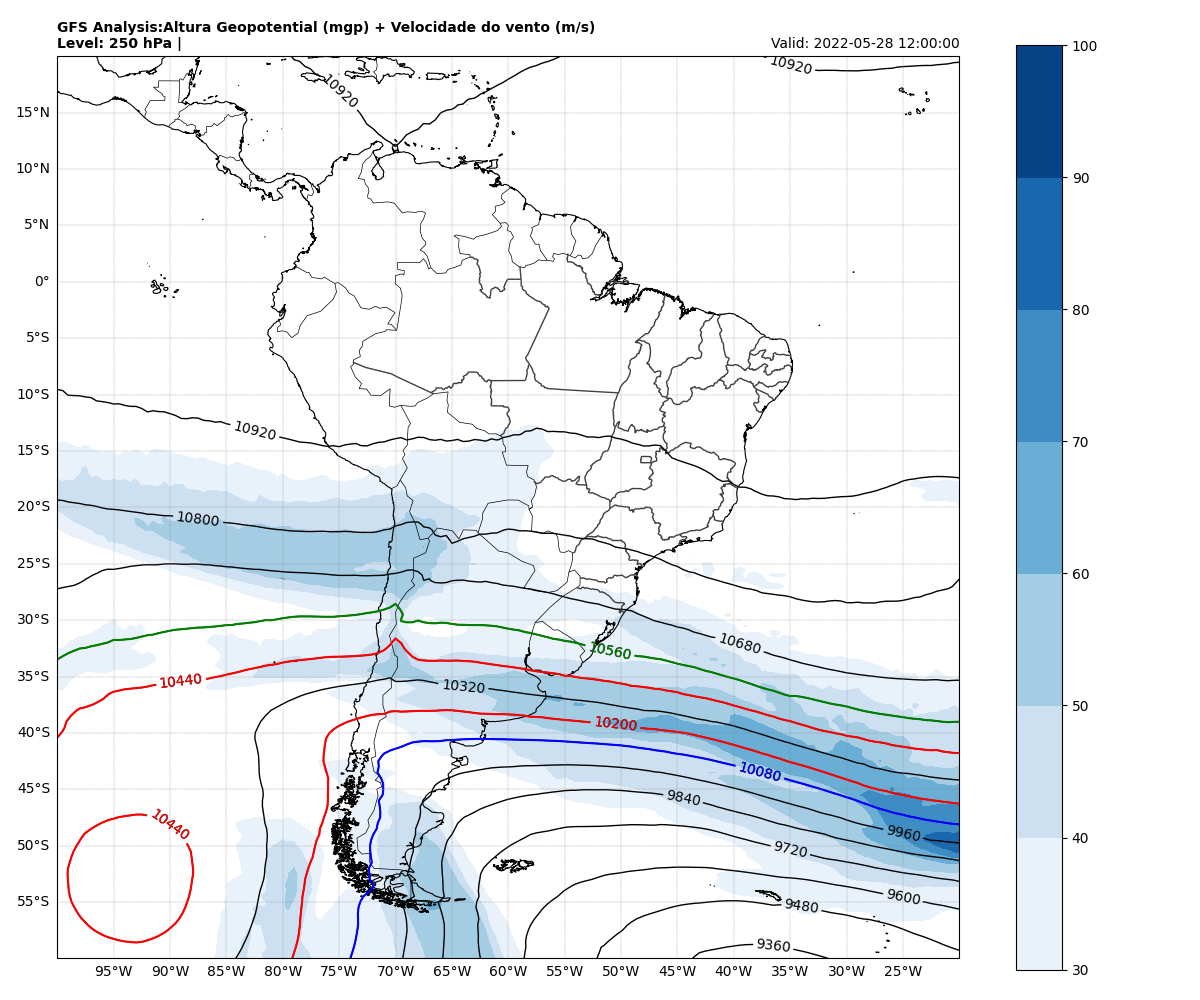

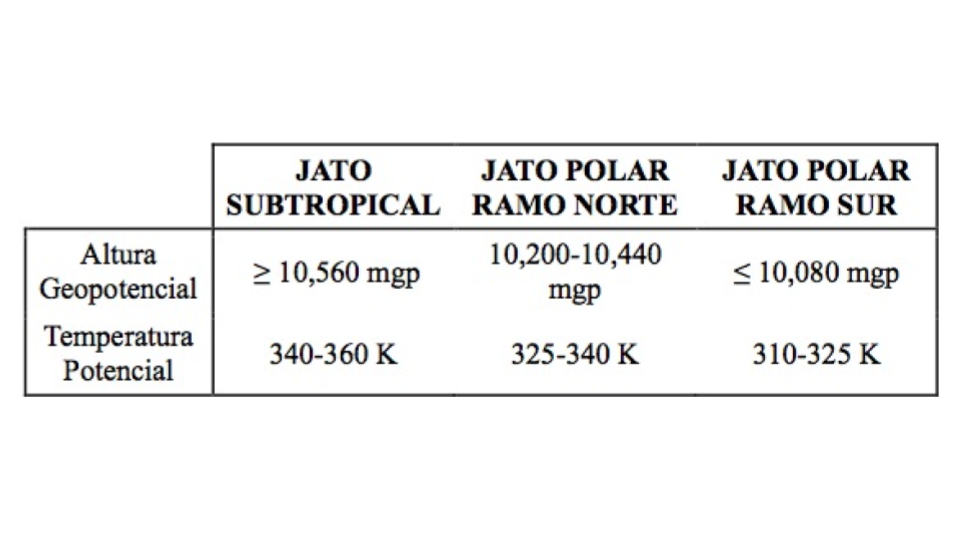

1. Criando variáveis para cada nível de pressão
2. Obter informalções do arquivo grib
Init: 2022-05-28 12:00:00UTC
Run: 12Z
Forecast: +0
Valid: 2022-05-28 12:00:00 UTC
3. Seleccionar extensão do mapa
4. Ler o dado sobre a região especificada - América do Sul
11. Criar a Figura
12. Asignar projeção ao mapa
13. Agregando linhas de costa, límites entre paises e linhas de grade
14. Agregando os estado de Brasil, The USA, e outros paises
15. Fazendo o plot do vento acima de 30 m/s
16. Agregando intervalos de contorno
17. Fazendo plot da variável
18. Critério de localização do jato
28. Salavando a figura .png


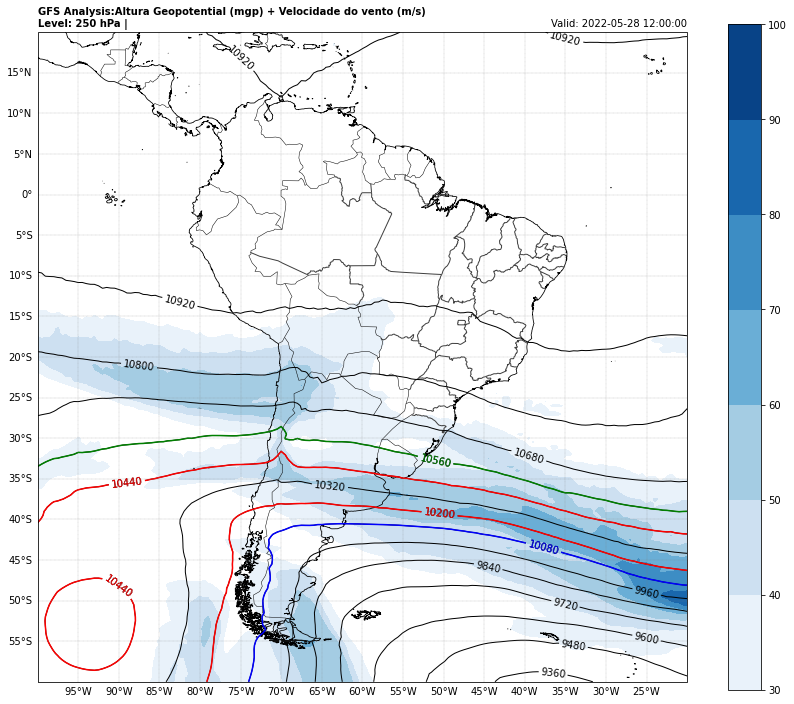

In [ ]:
# Criando as variáveis de hgt para cada nível de pressão
print("1. Criando variáveis para cada nível de pressão")

# Nível de 250 hPa
hgt_250 = gfs.select(name = "Geopotential Height")[1]
u_250 = gfs.select(name = "U component of wind")[1]
v_250 = gfs.select(name = "V component of wind")[1]

# Obter informações do arquivo
print("2. Obter informalções do arquivo grib")
init  = str(hgt_250.analDate)        # Init date / time
run   = str(hgt_250.hour).zfill(2)   # Run
ftime = str(hgt_250.forecastTime)    # Forecast hour
valid = str(hgt_250.validDate)       # Valid date / time
print('Init: ' + init + 'UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Seleccionar a extensão do mapa
print("3. Seleccionar extensão do mapa")
lat_min = -60
lat_max = 20
lon_min = -100
lon_max = -20
# Extensão do mapa
extent = [lon_min, lat_min, lon_max, lat_max]

# Ler o dado e extrair informação sobre a região especificada
print("4. Ler o dado sobre a região especificada - América do Sul")
# Nível de 850
u_250, lats, lons = u_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 500
v_250, lats, lons = v_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 250
hgt_250, lats, lons = hgt_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)

# Criando a variável de velocidade do vento
wspd_250 = (u_250**2 + v_250**2)**0.5

# ----------------------------------------------------------------------------------------------------------------
# Crian uma figura
print("11. Criar a Figura")
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'projection':ccrs.PlateCarree()}, sharey=True)

# FAZENDO O PRIMER MAPA PARA O NÍVEL DE 850 hPa

# ***********************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("12. Asignar projeção ao mapa")
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
img_extent = [extent[0], extent[2], extent[1], extent[3]]

# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LongitudeFormatter())

print("13. Agregando linhas de costa, límites entre paises e linhas de grade")
# Agregar linhas de costa
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar os límites entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
# Agregar linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("14. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# FAZENDO O PLOT DA VELOCIDADE DO VENTO >= 30 m/s
print("15. Fazendo o plot do vento acima de 30 m/s")
vel_min = 30
vel_max = 105
interval = 10
intensidade = np.arange(vel_min, vel_max, interval)

# Plot da variável velocidade do vento em 250 hPa maior ou igual 30ms
jato_250 = ax.contourf(lons, lats, wspd_250, cmap = 'Blues', levels = intensidade)
plt.colorbar(jato_250, pad = 0.05, orientation = 'vertical')

# -----------------------------------------------------------------------------------------------------------------------
# Definindo intervalos de contorno
print("16. Agregando intervalos de contorno")
hgt_250min = 9000
hgt_250max = 11000
interval = 120
levels = np.arange(hgt_250min, hgt_250max, interval)

# plot da variável
print("17. Fazendo plot da variável")
img_250 = ax.contour(lons, lats, hgt_250, colors = 'black', linestyles = 'solid',linewidths = 1, levels = levels)
ax.clabel(img_250, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'black')

# Agregando titulo ao mapa
ax.set_title('GFS Analysis:Altura Geopotential (mgp) + Velocidade do vento (m/s)\nLevel: 250 hPa |',\
             fontweight='bold', fontsize=10, loc='left')
ax.set_title('Valid: ' + valid, fontsize=10, loc='right')

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# FAZENDO ISOHIPSAS PARA A LOCALIZAÇÃO DO JATO

print("18. Critério de localização do jato")
# Jato Polar Norte    -> [10200 mgp - 10440 mgp]
hgt_polar_norte = np.arange(10200, 10441, 240)
JPN = ax.contour(lons, lats, hgt_250, colors = 'red', linestyles = 'solid', linewidths = 1.5, levels = hgt_polar_norte)
ax.clabel(JPN, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'red')

# Jato Polar Sur      -> Menor ou igual 10080 mgp 
hgt_polar_sul = np.arange(10080, 10081, 100)
JPS = ax.contour(lons, lats, hgt_250, colors = 'blue', linestyles = 'solid', linewidths = 1.5, levels = hgt_polar_sul)
ax.clabel(JPS, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'blue')

# Jato Subtropical    -> Maior ou igual 10560 mgp
hgt_subtropical = np.arange(10560, 10561, 100)
JST = ax.contour(lons, lats, hgt_250, colors = 'green', linestyles = 'solid', linewidths = 1.5, levels = hgt_subtropical)
ax.clabel(JST, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'green')

# Menos espaços em branco
fig.tight_layout()

print("28. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_06/jato250_hgt250_' + f'{init}.png', format='png', dpi = 100)